In [ ]:
!unzip -q /content/datasetsampah.zip -d /content/dataset_sampah

In [ ]:
!ls /content/dataset_sampah


TrashType_Image_Dataset


Memulai inisialisasi parameter...
Menyiapkan Data Generator...
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Membangun Arsitektur Model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
=== MULAI TAHAP 1: TRAINING CLASSIFIER ===
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 707ms/step - accuracy: 0.3577 - loss: 1.5502 - val_accuracy: 0.5527 - val_loss: 1.2255
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 494ms/step - accuracy: 0.4926 - loss: 1.2525 - val_accuracy: 0.6183 - val_loss: 1.0821
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 475ms/step - accuracy: 0.5623 - loss: 1.1029 - val_accuracy: 0.6581 - val_loss: 0.9954
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 488ms/step - accuracy: 0.5998 - loss: 1.0286 - val_accuracy: 0.6640 - val_loss: 0.9723
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 483ms/step - accuracy: 0.6166 - loss: 0.9707 - val_accuracy: 0.6859 - val_loss: 0.9130
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 478ms/step - accuracy: 0.6334 - loss: 0.927

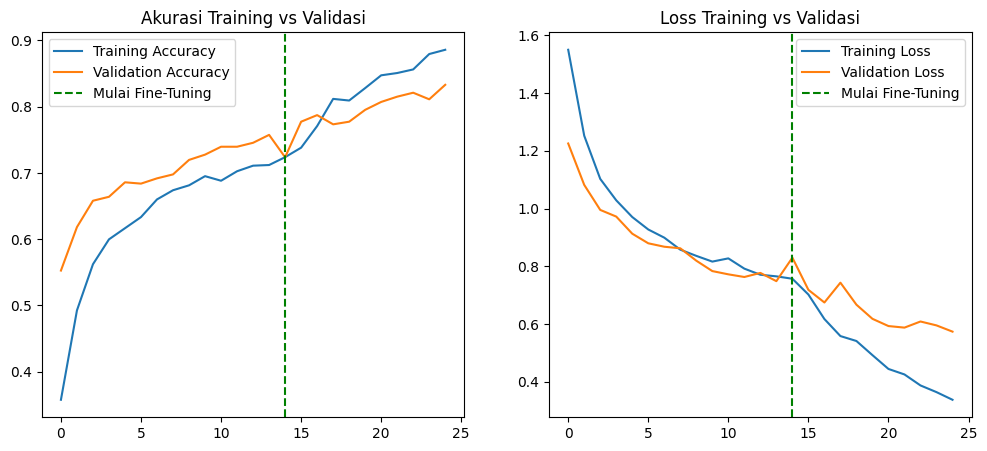

Proses Selesai! Model siap digunakan.


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("Memulai inisialisasi parameter...")
# 1. SETUP DIREKTORI & PARAMETER
DATA_DIR = '/content/dataset_sampah/TrashType_Image_Dataset' # Path yang sudah disesuaikan
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# 2. DATA AUGMENTATION & GENERATOR
print("Menyiapkan Data Generator...")
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 3. BUILD MODEL: TRANSFER LEARNING (VGG16)
print("Membangun Arsitektur Model...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Strategy 3: Fixed Feature Extractor (Freeze semua layer dasar)
for layer in base_model.layers:
    layer.trainable = False

# Tambahkan Classifier & Layer Dropout untuk Handling Overfitting
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x) # Matikan 50% neuron secara acak

NUM_CLASSES = len(train_generator.class_indices)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 4. TAHAP TRAINING 1: TRANSFER LEARNING
print("=== MULAI TAHAP 1: TRAINING CLASSIFIER ===")
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

# 5. TAHAP TRAINING 2: FINE-TUNING
print("=== MULAI TAHAP 2: FINE-TUNING ===")
# Unfreeze 4 layer konvolusi terakhir VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Compile ulang dengan Learning Rate sangat kecil
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# 6. VISUALISASI HASIL (Cek Overfitting)
print("Membuat grafik performa model...")
acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(14, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Akurasi Training vs Validasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(14, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Loss Training vs Validasi')
plt.legend()
plt.show()

print("Proses Selesai! Model siap digunakan.")

In [5]:
# 1. Simpan model ke dalam file .h5
model.save('model_deteksi_sampah_kampus.h5')
print("Model berhasil dibungkus dan disimpan!")

# 2. Perintah untuk memunculkan pop-up download otomatis ke laptopmu
from google.colab import files
files.download('model_deteksi_sampah_kampus.h5')

Model berhasil dibungkus dan disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>